# FWI · Acoustic · Marmousi

End-to-end SWEEP workflow on Marmousi (25 m grid spacing, 4 s record) with
zero external downloads. The compiled CUDA backend (`impl='c'`) is the default;
`PropTorch` falls back to eager automatically if the binding is missing.

1. load embedded true / smooth velocity models from `sweep.datasets`
2. build geometry, wavelet, and solver
3. forward-model the observed data
4. invert the smooth start with Adam + MSE
5. compare true / initial / inverted models

## Note on Adam `eps`

FWI gradients on real-amplitude wavefields can be tiny (10⁻¹⁰ or smaller).
PyTorch's default Adam `eps=1e-8` is too large &mdash; the denominator
`sqrt(v) + eps` would mask the real gradient. We use `eps=1e-16` below.


## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh    = MARMOUSI_DH * 2   # 25 m (12.5 m -> 25 m via ::2,::2 downsample)
dt    = 0.002
nt    = 2000              # 4.0 s
freq  = 5.0
delay = 0.20
nshots, nrec, batch_shots = 20, 200, 8
src_z, rec_z = 2, 4

lr, n_iter = 25.0, 30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Load Marmousi and downsample to 25 m


shape: (141, 681)    physical extent: 3.5 km depth × 17.0 km offset


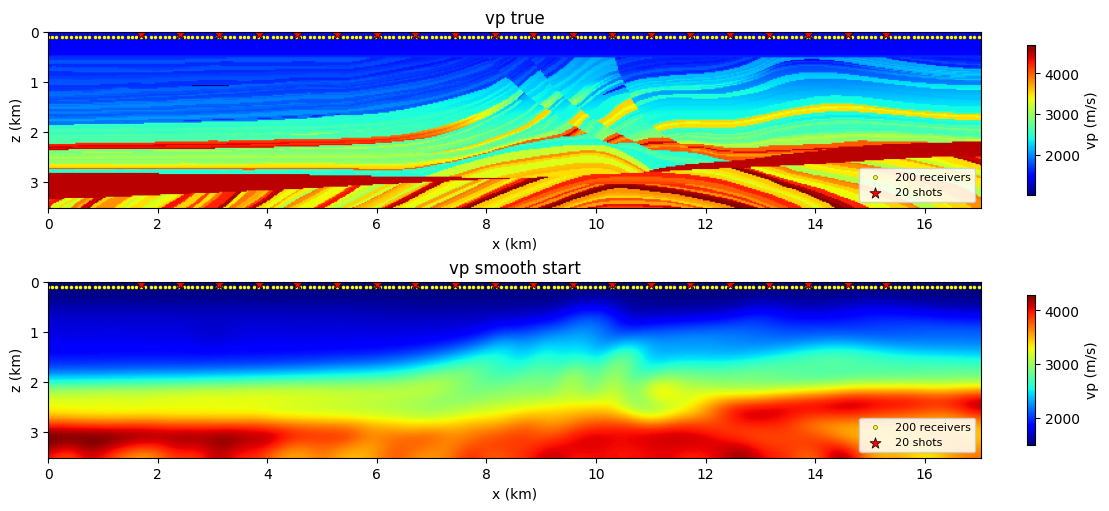

In [2]:
vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape      = vp_true_np.shape
print('shape:', shape, '   physical extent:',
      f'{shape[0]*dh/1000:.1f} km depth × {shape[1]*dh/1000:.1f} km offset')

# Acquisition geometry: surface sources + horizontal receiver line
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
src_x_km = src_x * dh / 1000;  src_z_km = src_z * dh / 1000
rec_x_km = rec_x * dh / 1000;  rec_z_km = rec_z * dh / 1000

fig, axes = plt.subplots(2, 1, figsize=(11, 5), constrained_layout=True)
for ax, m, title in zip(axes, [vp_true_np, vp_init_np], ['true', 'smooth start']):
    im = ax.imshow(m, cmap='jet', aspect='auto',
                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
    ax.scatter(rec_x_km, np.full_like(rec_x_km, rec_z_km, dtype=float),
               s=8, c='yellow', edgecolors='k', linewidths=0.3, label=f'{nrec} receivers')
    ax.scatter(src_x_km, np.full_like(src_x_km, src_z_km, dtype=float),
               s=70, c='red', marker='*', edgecolors='k', linewidths=0.5, label=f'{nshots} shots')
    ax.set_title(f'vp {title}')
    ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.85)
    fig.colorbar(im, ax=ax, label='vp (m/s)', shrink=0.85)
plt.show()


## 3. Geometry, wavelet, solver

Solver uses the compiled CUDA backend (`impl='c'`). Every other knob is at
its default: `spatial_order=4`, `abcn=50`, `pml_type='cpmlr'`,
`free_surface=False`, `use_ckpt=True`.

In [3]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)

sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

equation = Acoustic(device=device)
solver   = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl='c')
# eager-mode chunk autograd holds activations for a full chunk; shrink the
# stochastic mini-batch when the C path is unavailable so memory stays low.
if solver.impl == 'eager':
    batch_shots = min(batch_shots, 2)
print('impl:', solver.impl, ' batch_shots:', batch_shots)


impl: c  batch_shots: 8


### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 4. Forward modeling — observed data

observed shape: (20, 2000, 200, 1)


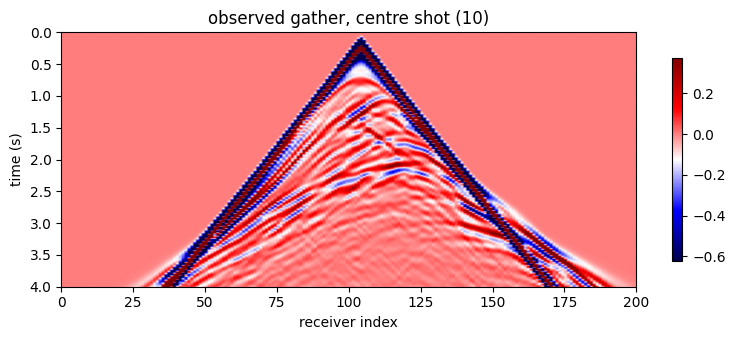

In [5]:
vp_true = torch.tensor(vp_true_np, device=device)
models_true = [vp_true]

with torch.no_grad():
    observed = solver(wavelet, sources, receivers, models=models_true).detach()
print('observed shape:', tuple(observed.shape))



gather0 = observed[nshots // 2].squeeze().detach().cpu().numpy()
if gather0.shape[0] != nt:
    gather0 = gather0.T
vmin, vmax = np.percentile(gather0, [2, 98])
plt.figure(figsize=(8, 3.5))
plt.imshow(gather0, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
           extent=[0, nrec, nt * dt, 0])
plt.xlabel('receiver index'); plt.ylabel('time (s)')
plt.title(f'observed gather, centre shot ({nshots // 2})')
plt.colorbar(shrink=0.8); plt.tight_layout(); plt.show()

## 5. Stochastic Adam loop (mini-batch shots)

Each iteration uses a **random batch of `batch_shots` shots out of `nshots`**
so the per-iteration cost stays small even when `nshots` is large. Acoustic FWI
gradients are tiny, so `eps=1e-16` (PyTorch default `1e-8` would mask them).

In [6]:
import time
rng = np.random.default_rng(0)
t_start = time.time()
vp = torch.tensor(vp_init_np, device=device, requires_grad=True)
optimizer = torch.optim.Adam([vp], lr=lr, eps=1e-16)
losses = []

for it in range(n_iter):
    iter_t0 = time.time()
    idx = rng.choice(nshots, size=batch_shots, replace=False)
    optimizer.zero_grad()
    predicted = solver(wavelet, sources[idx], receivers[idx], models=[vp])
    loss = (predicted - observed[idx]).pow(2).mean()
    loss.backward()
    optimizer.step()
    if device.type == "cuda":
        torch.cuda.synchronize()
    iter_t = time.time() - iter_t0
    losses.append(float(loss.detach().cpu()))
    print(f'iter {it:02d}  loss {losses[-1]:.4e}  iter={iter_t:.2f}s  total={time.time()-t_start:.1f}s')


iter 00  loss 5.4433e-02  iter=0.35s  total=0.3s


iter 01  loss 3.3808e-02  iter=0.21s  total=0.6s


iter 02  loss 3.9055e-02  iter=0.22s  total=0.8s


iter 03  loss 2.6431e-02  iter=0.22s  total=1.0s


iter 04  loss 1.4612e-02  iter=0.22s  total=1.2s


...

iter 25  loss 6.2410e-03  iter=0.23s  total=5.9s


iter 26  loss 5.1031e-03  iter=0.23s  total=6.2s


iter 27  loss 4.9210e-03  iter=0.23s  total=6.4s


iter 28  loss 3.7805e-03  iter=0.23s  total=6.6s


iter 29  loss 3.1948e-03  iter=0.23s  total=6.8s


## 6. Results

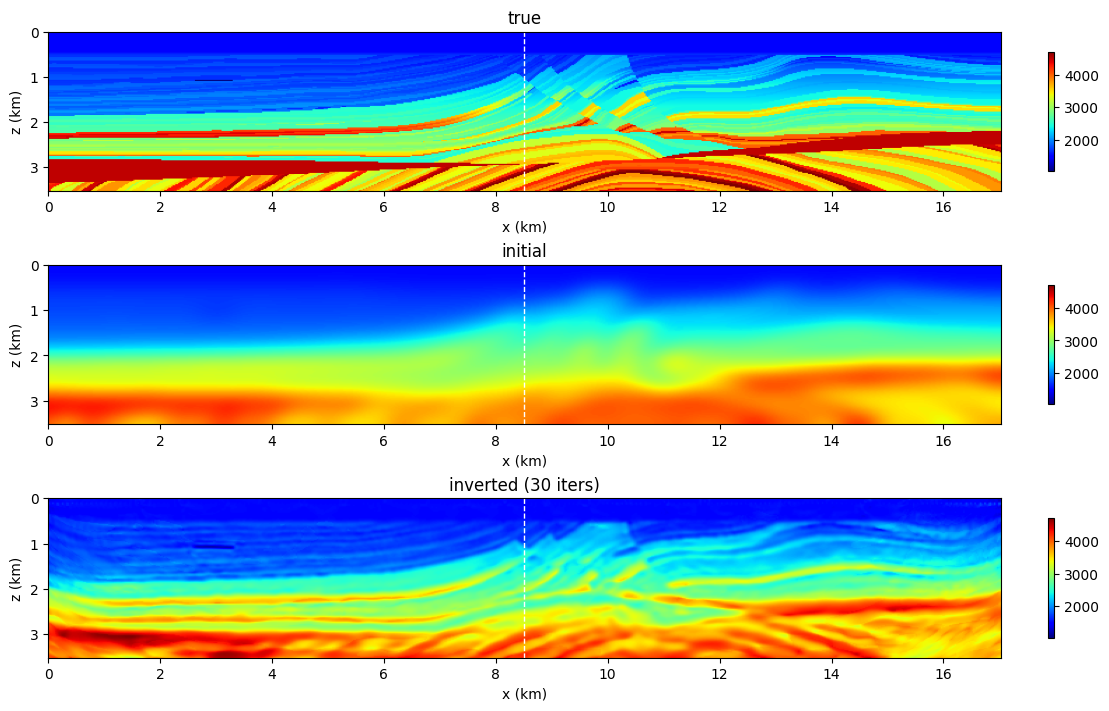

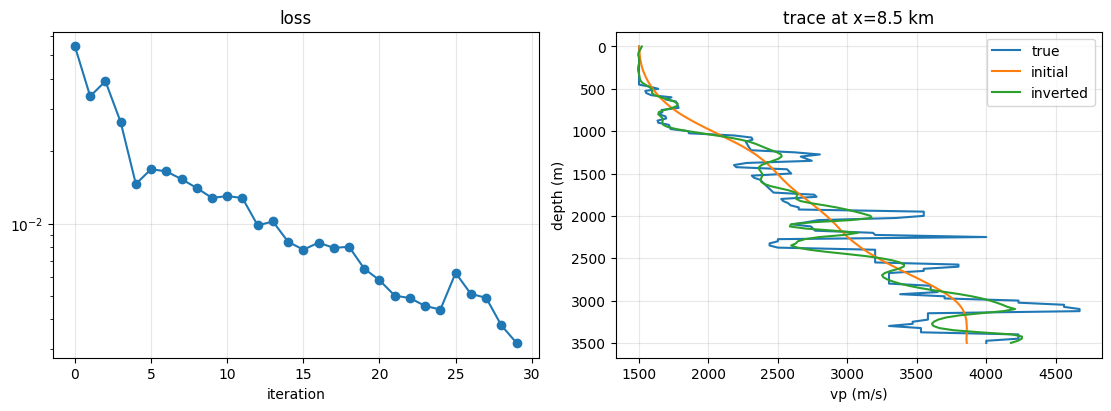

In [7]:
vp_final = vp.detach().cpu().numpy()
vmin_m = float(min(vp_true_np.min(), vp_init_np.min(), vp_final.min()))
vmax_m = float(max(vp_true_np.max(), vp_init_np.max(), vp_final.max()))
x_trace = shape[1] // 2
z_axis = np.arange(shape[0]) * dh

fig, axes = plt.subplots(3, 1, figsize=(11, 7), constrained_layout=True)
for ax, m, title in zip(
    axes,
    [vp_true_np, vp_init_np, vp_final],
    ['true', 'initial', f'inverted ({n_iter} iters)'],
):
    im = ax.imshow(m, cmap='jet', vmin=vmin_m, vmax=vmax_m, aspect='auto',
                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
    ax.axvline(x_trace * dh / 1000, color='w', linewidth=1.0, linestyle='--')
    ax.set_title(title); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(losses, marker='o')
axes[0].set_title('loss'); axes[0].set_xlabel('iteration')
axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)
axes[1].plot(vp_true_np[:, x_trace], z_axis, label='true')
axes[1].plot(vp_init_np[:, x_trace], z_axis, label='initial')
axes[1].plot(vp_final[:, x_trace],   z_axis, label='inverted')
axes[1].invert_yaxis()
axes[1].set_xlabel('vp (m/s)'); axes[1].set_ylabel('depth (m)')
axes[1].set_title(f'trace at x={x_trace * dh / 1000:.1f} km')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.show()

## 7. Bonus · source-encoding FWI (multi-source super-shot)

The standard loop above runs `batch_shots` forward simulations per iteration.
**Source encoding** (Krebs et al., 2009) instead sums all shots — each tagged
with a random ±1 sign — into a single *super-shot* and runs **one** forward
per iteration. The cross-talk between shots averages out over iterations as
the signs are re-drawn each step.

To trigger source-encoding mode in sweep, pack the inputs into the canonical
`(1, nsrc, …)` layout — the propagator auto-detects the mode from the
shapes (no `source_encoding=` flag):

- `wavelet`:   `(nsrc, nt)`     each source carries its own (scaled) wavelet
- `sources`:   `(1, nsrc, 2)`   one super-shot batch with `nsrc` point sources
- `receivers`: `(1, nrec, 2)`   shared receiver line (taken from any shot)

The forward returns a single super-gather of shape `(1, nt, nrec, 1)`.

iter 00  loss 1.2533e+00  iter=0.07s  total=0.1s
iter 01  loss 5.5525e-01  iter=0.07s  total=0.1s
iter 02  loss 7.1299e-01  iter=0.07s  total=0.2s


iter 03  loss 5.0143e-01  iter=0.07s  total=0.3s
iter 04  loss 3.3809e-01  iter=0.07s  total=0.4s
iter 05  loss 3.3151e-01  iter=0.07s  total=0.4s


iter 06  loss 3.4698e-01  iter=0.07s  total=0.5s
iter 07  loss 2.9772e-01  iter=0.07s  total=0.6s
iter 08  loss 2.3302e-01  iter=0.07s  total=0.6s


iter 09  loss 2.4871e-01  iter=0.07s  total=0.7s
iter 10  loss 2.8644e-01  iter=0.07s  total=0.8s
iter 11  loss 2.5667e-01  iter=0.07s  total=0.8s


iter 12  loss 1.6779e-01  iter=0.07s  total=0.9s
iter 13  loss 1.3610e-01  iter=0.07s  total=1.0s
iter 14  loss 1.2947e-01  iter=0.07s  total=1.0s


iter 15  loss 1.5044e-01  iter=0.07s  total=1.1s
iter 16  loss 1.2461e-01  iter=0.07s  total=1.2s
iter 17  loss 1.2659e-01  iter=0.07s  total=1.2s
iter 18  loss 1.4640e-01  iter=0.07s  total=1.3s


iter 19  loss 1.4189e-01  iter=0.07s  total=1.4s
iter 20  loss 9.2400e-02  iter=0.07s  total=1.4s
iter 21  loss 7.8242e-02  iter=0.07s  total=1.5s
iter 22  loss 1.0396e-01  iter=0.07s  total=1.6s


iter 23  loss 9.4500e-02  iter=0.07s  total=1.6s
iter 24  loss 6.8928e-02  iter=0.07s  total=1.7s
iter 25  loss 6.3217e-02  iter=0.07s  total=1.8s


iter 26  loss 7.6141e-02  iter=0.07s  total=1.8s
iter 27  loss 7.7729e-02  iter=0.07s  total=1.9s
iter 28  loss 6.4582e-02  iter=0.07s  total=2.0s


iter 29  loss 5.7831e-02  iter=0.07s  total=2.0s


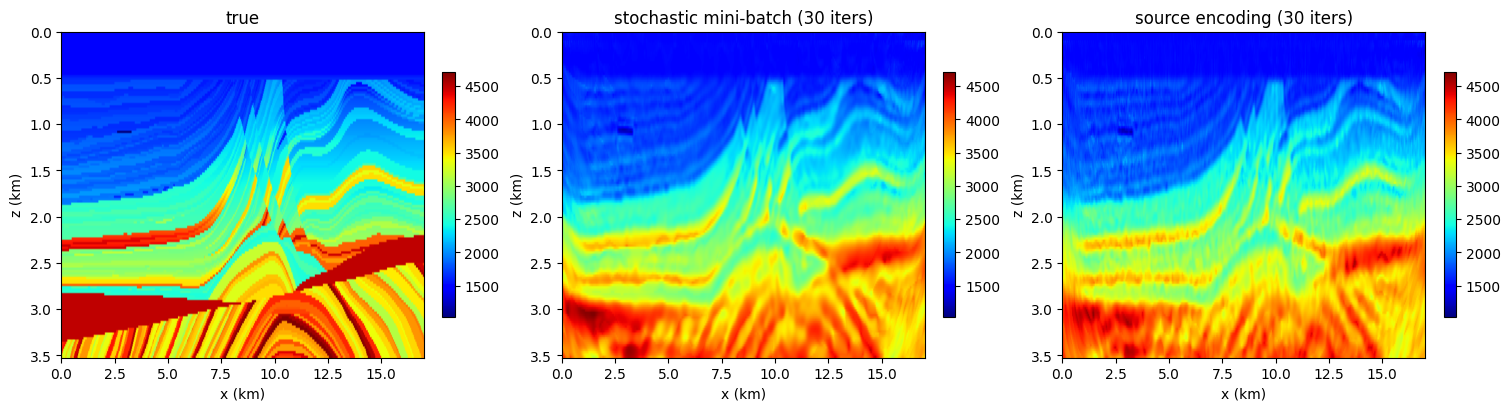

In [8]:
# Use a fresh solver for the encoded loop so the C-backend checkpoint
# buffer is sized for the super-shot's B=1 from the start (the existing
# `solver` had its buffer allocated for batch_shots=8).
solver_se = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl=solver.impl)

vp_se = torch.tensor(vp_init_np, device=device, requires_grad=True)
optimizer_se = torch.optim.Adam([vp_se], lr=lr, eps=1e-16)
losses_se = []

# All shots share the same receiver line — take the first row as the shared
# (1, nrec, 2) receiver array for the encoded super-shot.
receivers_se = receivers[:1]
sources_se   = sources[None, ...]   # (1, nshots, 2)

n_iter_se = n_iter
rng_se = np.random.default_rng(1)
t_start = time.time()

for it in range(n_iter_se):
    iter_t0 = time.time()
    signs = rng_se.choice([-1.0, 1.0], size=nshots).astype(np.float32)

    # Per-source wavelet: same base wavelet, scaled by ±1 -> shape (nshots, nt)
    wavelet_enc = (signs[:, None] * wavelet[None, :]).astype(np.float32)

    # Encode the observed data the same way: signs along the shot axis, sum.
    obs_enc = (observed * torch.from_numpy(signs).to(device)[:, None, None, None]).sum(0, keepdim=True)

    optimizer_se.zero_grad()
    predicted = solver_se(wavelet_enc, sources_se, receivers_se, models=[vp_se])
    loss = (predicted - obs_enc).pow(2).mean()
    loss.backward()
    optimizer_se.step()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    losses_se.append(float(loss.detach().cpu()))
    print(f'iter {it:02d}  loss {losses_se[-1]:.4e}  iter={time.time()-iter_t0:.2f}s  total={time.time()-t_start:.1f}s')

vp_se_final = vp_se.detach().cpu().numpy()

# Side-by-side: stochastic mini-batch result vs source-encoding result
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, m, title in zip(
    axes,
    [vp_true_np, vp_final, vp_se_final],
    ['true', f'stochastic mini-batch ({n_iter} iters)', f'source encoding ({n_iter_se} iters)'],
):
    im = ax.imshow(m, cmap='jet', vmin=vmin_m, vmax=vmax_m, aspect='auto',
                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
    ax.set_title(title); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()


---

<p><strong>Download this notebook</strong> &mdash; <a href="01_fwi_acoustic_marmousi.ipynb" download><code>01_fwi_acoustic_marmousi.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/01_fwi_acoustic_marmousi.ipynb">view on GitHub</a></p>